In [19]:
from mace.calculators import MACECalculator
import numpy as np
import pandas as pd
import ase
from ase import Atom, Atoms

from ase.build import graphene
from ase.optimize import BFGS

from ase.filters import ExpCellFilter

from ase.visualize import view

from ase.io import write

import matplotlib.pyplot as plt

from tqdm import tqdm


In [2]:
model = MACECalculator("../../MACE.model", device = "cuda")

/home/gabri/anaconda3/envs/mace/lib/python3.10/site-packages/mace/calculators/mace.py:199: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  torch.load(f=model_path, map_location=device)
/home/gabri/anaconda3/envs/mace/lib/python3.10/site-packages/torch/jit/_serialization.py:176: DeprecationWarning: `torch.jit.load` is deprecated. Please switch to `torch.export`.
  warnings.warn(
/home/gabri/anaconda3/envs/mace/lib/python3.10/site-packages/torch/jit/_serialization.py:176: DeprecationWarning: `torch.jit.load` is deprecated. Please switch to `torch.export`.
  warnings.warn(
/home/gabri/anaconda3/envs/mace/lib/python3.10/site-packages/torch/jit/_serialization.py:176: DeprecationWarning: `torch.jit.load` is deprecated. Please switch to `torch.export`.
  warnings.warn(


In [3]:
primitive = graphene()
primitive.cell[2] = [0,0,100]
filter = ExpCellFilter(primitive, mask = [1,1,0,0,0,0])
primitive.calc = model

opt = BFGS(filter)
opt.run(fmax = 1e-5)

/tmp/ipykernel_456927/1072062919.py:3: DeprecationWarning: Use FrechetCellFilter for better convergence w.r.t. cell variables.
  filter = ExpCellFilter(primitive, mask = [1,1,0,0,0,0])


      Step     Time          Energy          fmax
BFGS:    0 17:57:16      -15.917213        0.014590
BFGS:    1 17:57:16      -15.917210        0.029138
BFGS:    2 17:57:17      -15.917217        0.000014
BFGS:    3 17:57:17      -15.917215        0.000023
BFGS:    4 17:57:17      -15.917215        0.000035
BFGS:    5 17:57:17      -15.917215        0.000027
BFGS:    6 17:57:17      -15.917215        0.000014
BFGS:    7 17:57:17      -15.917213        0.000039
BFGS:    8 17:57:17      -15.917215        0.000005


np.True_

In [4]:
cell0 = primitive.cell.copy()
a0 = np.linalg.norm(cell0[0])
l0 = primitive.get_all_distances()[0][1]

In [5]:
a0

np.float64(2.459828903851156)

In [6]:
def generate_primitive(latticeparam=2.46):
    a = latticeparam

    # Primitive vectors rotated 30° relative to your original.
    # a1 points at 30°, a2 points at 90° — armchair direction is now along X.
    cell = np.array([
        [0.5 * np.sqrt(3) * a,  0.5 * a, 0],   # a1 at 30°
        [0,                      a,       0],   # a2 at 90°
        [0,                      0,      20.0]
    ])

    # Same fractional coordinates as your original — still valid graphene
    positions_frac = np.array([
        [1/3, 1/3, 0],
        [2/3, 2/3, 0]
    ])

    xyz_positions = positions_frac @ cell

    atoms = Atoms("C2",
                  positions=xyz_positions,
                  cell=cell,
                  pbc=(True, True, False))

    return atoms

In [34]:
primitive = generate_primitive(2.4598288248992755)
view(primitive.repeat((5,5,1)), viewer="ngl")

In [9]:
KCELL0 = 3*l0* np.array([
    [1,0,0],
    [0.5, np.sqrt(3)/2, 0],
    [0,0,100]
])
# in K cell 0 primitive direction
KBASE0 = (1/3.) * np.array([
    [1, 0, 0],
    [2, 0, 0],
    [2, 1, 0],
    [1, 2, 0],
    [0, 1, 0],
    [0, 2, 0]
])

katoms = Atoms("C6", positions = KBASE0 @ KCELL0, cell=KCELL0, pbc = [True, True, True])


In [11]:
opt = BFGS(atoms=katoms)
katoms.calc = model
opt.run(fmax = 1e-5)

      Step     Time          Energy          fmax
BFGS:    0 18:01:41      -47.751644        0.000015
BFGS:    1 18:01:41      -47.751644        0.000008


np.True_

In [ ]:
strains = np.linspace(2, 0.3, 30)
strains_tensors = [np.array([
    [s, 0, 0],
    [0, 0, 0],
    [0, 0, 0]
]) for s in strains]
id = np.eye(3)
deformations = [id + s for s in strains_tensors]

In [69]:
def stress_strain(strain_template, atoms, supercell = (1,1,1)):

    cell0 = atoms.cell.copy()
    strains = np.linspace(0.2, 0.3, 30)
    strains_tensors = [strain_template * s for s in strains]
    id = np.eye(3)
    deformations = [id + s for s in strains_tensors]

    stresses = []

    for deform in tqdm(deformations):
        cell = cell0 @ deform
        strained_atoms = atoms.copy()
        strained_atoms = strained_atoms.repeat(supercell)
        strained_atoms.set_cell(cell, scale_atoms=True)
        strained_atoms.pbc = (True, True, True)
        strained_atoms.calc = model
        perturbations = np.random.normal(0, 1e-2, size=(len(strained_atoms),3))
        strained_atoms.positions += perturbations
        opt = BFGS(strained_atoms, logfile=None)
        opt.run(fmax = 1e-4)

        stress = strained_atoms.get_stress()
        stresses.append(stress)

    # Apply your scaling factor to the raw stress array
    stresses = (np.array(stresses) * cell0[2,2]) / np.sqrt(2)
    
    # Combined stress for plotting
    y_values = stresses[:,0] + stresses[:,1]
    
    plt.plot(strains, y_values)
    
    maxi = np.argmax(y_values)
    maxstrain = strains[maxi]
    # Scaling the displayed max stress by sqrt(2) per your label request
    max_val_label = y_values[maxi] / np.sqrt(2)
    
    plt.scatter(maxstrain, y_values[maxi], marker = "x", color = "red", 
                label = f"max strain {maxstrain:.3f}\nmax $(\sigma_{{xx}} + \sigma_{{yy}})/\sqrt{{2}}$: {max_val_label:.3f}")

    plt.legend(fontsize = 14)
    plt.xlabel("Strain Amplitude", fontsize = 14)
    plt.ylabel(r"Planar Stress $(\sigma_{xx} + \sigma_{yy})/\sqrt{2}$ [eV/Å$^2$]", fontsize= 14)
    plt.grid()

<>:40: DeprecationWarning: invalid escape sequence '\s'


In [70]:
STRAINXX = np.array(([1,0,0], [0,0,0], [0,0,0]))
STRAINYY = np.array(([0,0,0], [0,1,0], [0,0,0]))
STRAINEQUI = (STRAINXX + STRAINYY) / np.sqrt(2)

100%|██████████| 30/30 [00:11<00:00,  2.72it/s]


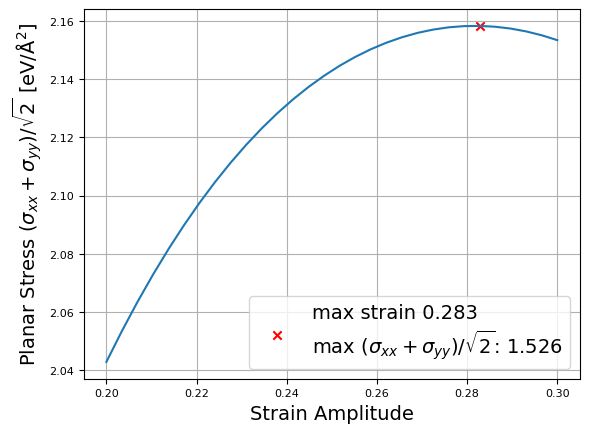

In [71]:
stress_strain(STRAINYY, primitive)

100%|██████████| 30/30 [00:41<00:00,  1.38s/it]


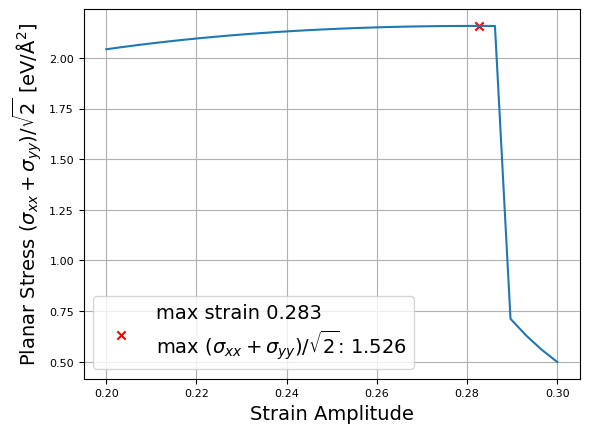

In [72]:
stress_strain(STRAINYY, katoms)

100%|██████████| 30/30 [00:07<00:00,  4.04it/s]


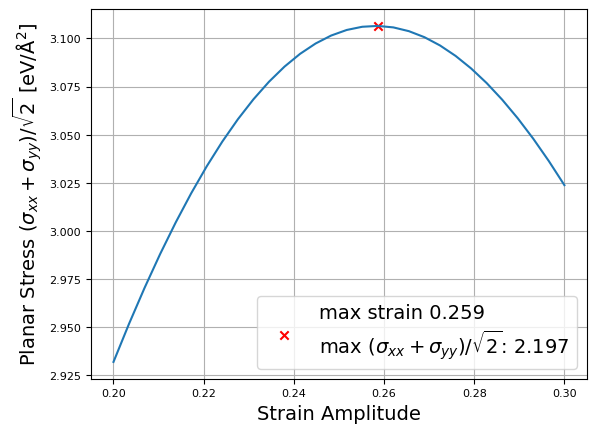

In [73]:
stress_strain(STRAINEQUI, primitive)

100%|██████████| 30/30 [00:55<00:00,  1.86s/it]


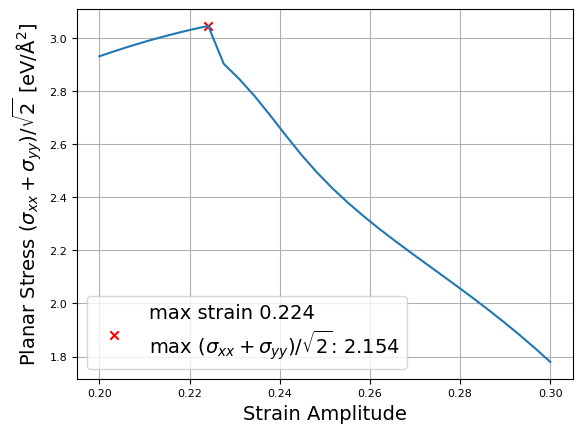

In [74]:
stress_strain(STRAINEQUI, katoms)

In [ ]:
stresses = []

for deform in tqdm(deformations):
    cell = cell0 @ deform
    strained_atoms = primitive.copy()
    strained_atoms.set_cell(cell, scale_atoms=True)
    strained_atoms.pbc = (True, True, True)
    strained_atoms.calc = model
    perturbations = np.random.normal(0, 1e-3, size=(len(strained_atoms),3))
    strained_atoms.positions += perturbations
    opt = BFGS(strained_atoms, logfile=None)
    opt.run(fmax = 1e-4)

    stress = strained_atoms.get_stress()
    stresses.append(stress)

100%|██████████| 100/100 [01:33<00:00,  1.07it/s]


In [14]:
stresses = np.array(stresses)

In [15]:
primitive.positions

array([[0.71009142, 1.22991441, 0.        ],
       [1.42018283, 2.45982882, 0.        ]])

max strain 0.24545454545454545
max stress 0.030236252


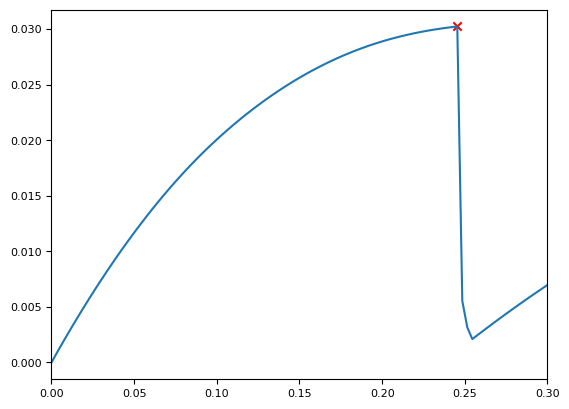

In [18]:
plt.plot(strains, stresses[:,1] + stresses[:,0])
maxi = np.argmax(stresses[:,1] + stresses[:,0])
maxs = stresses[maxi, 1] + stresses[maxi, 0]
maxstrain = strains[maxi]

plt.xlim(0., 0.30)
plt.scatter(maxstrain, maxs, marker="x", color="red")
# plt.ylim((maxs*0.95, maxs*1.01))

print("max strain", maxstrain)
print("max stress", maxs)

In [64]:

deformation = deformations[-10]
cell = cell0 @ deformation
deformed_atoms = primitive.copy()
deformed_atoms.set_cell(cell, scale_atoms=True)
deformed_atoms.pbc = (True, True, True)
deformed_atoms.calc = model

perturbations = np.random.normal(0, 0.01, size=(len(deformed_atoms),3))
deformed_atoms.positions += perturbations

opt = BFGS(deformed_atoms)
opt.run(fmax = 1e-4)

view(deformed_atoms.repeat((5,5,1)), viewer="ngl")

      Step     Time          Energy          fmax
BFGS:    0 15:40:49      -13.341009        0.702425
BFGS:    1 15:40:49      -13.347671        0.107645
BFGS:    2 15:40:49      -13.347894        0.064510
BFGS:    3 15:40:49      -13.348104        0.033825
BFGS:    4 15:40:49      -13.348137        0.018770
BFGS:    5 15:40:49      -13.348146        0.012185
BFGS:    6 15:40:49      -13.348153        0.009113
BFGS:    7 15:40:49      -13.348156        0.004193
BFGS:    8 15:40:49      -13.348155        0.000827
BFGS:    9 15:40:50      -13.348156        0.000053


In [45]:
stresses = np.array(stresses)

(0.14363636363636365, 0.17555555555555558)

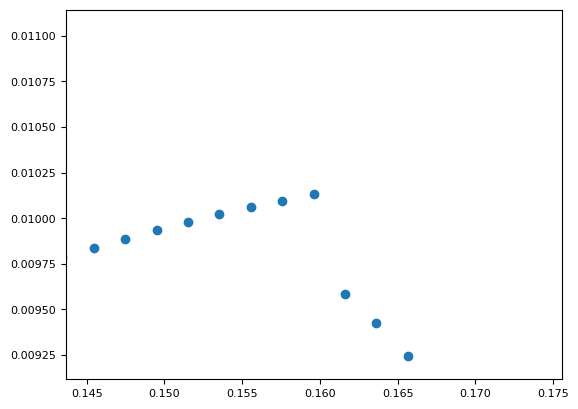

In [48]:
import matplotlib.pyplot as plt
plt.scatter(strains, stresses[:,0] + stresses[:, 1])
maxs = np.max(stresses[:, 1] + stresses[:,0])

maxi = np.argmax(stresses[:,0] + stresses[:, 1])
maxstress = stresses[maxi]
maxstressvalue = maxstress[0]+ maxstress[1]
maxstrain = strains[maxi]

plt.ylim(maxstressvalue*0.9, maxstressvalue*1.1)
plt.xlim(maxstrain*0.9, maxstrain*1.1)

In [150]:
SQRT2 = np.sqrt(2)
SQRT3 = np.sqrt(3)
HALFSQRT3 = SQRT3/2.

INVSQRT2 = 1./SQRT2
INVSQRT3 = 1./SQRT3

class BaseMode():
    def __init__(self):
        self.xyz_directions = None
        return
    
    def apply(self, atoms, amplitude):
        copy = atoms.copy()
        copy.positions += amplitude * self.xyz_directions

        return copy.copy()
    
class AMode(BaseMode):
    def __init__(self):
        super().__init__()

        d1 = np.array([1, 0, 0])
        d2 = np.array([INVSQRT2, -INVSQRT2, 0])
        d3 = np.array([0, 1, 0])
        self.directions = np.array([
            -d1,
            d1,
            d2,
            -d2,
            -d3,
            d3
        ])

        cell = np.array([
            [1, 0, 0],
            [0.5, HALFSQRT3, 0],
            [0, 0, 1]
        ])

        self.xyz_directions = self.directions @ cell

        return
    
class BMode(BaseMode):
    def __init__(self):
        super().__init__()

        d1 = [0, 1, 0]
        d2 = [-HALFSQRT3, -0.5, 0]
        d3 = [HALFSQRT3, -0.5, 0]
        self.xyz_directions = np.array([
            d1,
            d1,
            d2,
            d2,
            d3,
            d3
        ])

        return

BMODE = BMode()
AMODE = AMode()

In [147]:
def apply_a_mode(atoms, amplitude):    
    # relative to primitive directions
    # note that this is basis dependent
    copy = atoms.copy()
    copy.calc = model
    d1 = np.array([1, 0, 0])
    d2 = np.array([INVSQRT2, -INVSQRT2, 0])
    d3 = np.array([0, 1, 0])
    directions = np.array([
        -d1,
        d1,
        d2,
        -d2,
        -d3,
        d3
    ])

    xyz_directions = directions @ KCELL0
    xyz_displacements = amplitude * xyz_directions

    copy.positions += xyz_displacements

    pe = copy.get_potential_energy()

    return pe

def apply_b_mode(atoms, amplitude):
    # note that this is basis dependent

    copy = atoms.copy()
    copy.calc = model
    d1 = [0, 1, 0]
    d2 = [-HALFSQRT3, -0.5, 0]
    d3 = [HALFSQRT3, -0.5, 0]
    xyz_directions = np.array([
        d1,
        d1,
        d2,
        d2,
        d3,
        d3
    ])

    xyz_displacements = amplitude * xyz_directions

    copy.positions += xyz_displacements

    pe = copy.get_potential_energy()

    return pe

In [209]:
strain = 0.25
deformation = np.eye(3) + np.array([[strain, 0, 0], [0, strain, 0], [0, 0, 0]])

cell = KCELL0 @ deformation
strained_atoms = katoms.copy()
strained_atoms.set_cell(cell, scale_atoms=True)
strained_atoms.calc = model


In [210]:
amplitudes = np.linspace(-0.5, 0.5, 100)
energies = []
for a in tqdm(amplitudes):
    modded = BMODE.apply(strained_atoms, a)
    modded.calc = model
    energies.append(modded.get_potential_energy())

100%|██████████| 100/100 [00:04<00:00, 23.70it/s]


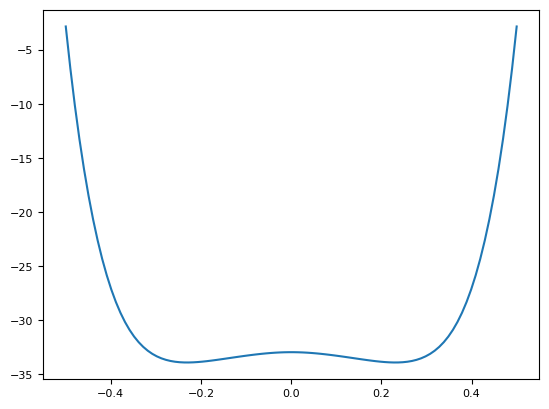

In [211]:
plt.plot(amplitudes, energies)
mini = np.argmin(energies)
mine = energies[mini]
mina = amplitudes[mini]
# plt.ylim(mine-0.01, mine+0.1)
# plt.xlim(mina-0.5, mina+0.5)

In [115]:
ID = np.eye(3)
strains = np.linspace(0, 0.40, num = 10)
deformations = [ID + np.array([[s, 0, 0], [0, s, 0], [0, 0, 0]]) for s in strains]
amplitudes = np.linspace(-0.1, 0.2, num=50)

AMODE_ENERGIES = {}

AMODE_ENERGIES['amplitudes'] = amplitudes

for strain, deformation in tqdm(zip(strains, deformations)):
    cell = KCELL0 @ deformation
    strained_atoms = katoms.copy()
    strained_atoms.set_cell(cell, scale_atoms=True)
    strained_atoms.calc = model

    energies = []
    for a in amplitudes:
        energies.append(apply_a_mode(strained_atoms, a))

    AMODE_ENERGIES[strain] = energies


10it [00:20,  2.05s/it]


In [138]:
amplitudes

array([-0.1       , -0.09387755, -0.0877551 , -0.08163265, -0.0755102 ,
       -0.06938776, -0.06326531, -0.05714286, -0.05102041, -0.04489796,
       -0.03877551, -0.03265306, -0.02653061, -0.02040816, -0.01428571,
       -0.00816327, -0.00204082,  0.00408163,  0.01020408,  0.01632653,
        0.02244898,  0.02857143,  0.03469388,  0.04081633,  0.04693878,
        0.05306122,  0.05918367,  0.06530612,  0.07142857,  0.07755102,
        0.08367347,  0.08979592,  0.09591837,  0.10204082,  0.10816327,
        0.11428571,  0.12040816,  0.12653061,  0.13265306,  0.13877551,
        0.14489796,  0.15102041,  0.15714286,  0.16326531,  0.16938776,
        0.1755102 ,  0.18163265,  0.1877551 ,  0.19387755,  0.2       ])

In [136]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as colors
import numpy as np

def plot_mode_energy(mode_energy):
    amplitudes = mode_energy['amplitudes']
    # Filter strains and convert to floats for the colorbar scale
    strains = [s for s in mode_energy.keys() if s != "amplitudes"]
    strain_values = [float(s) for s in strains]

    # 1. Create a Normalize object to map strain values to the [0, 1] range
    norm = colors.Normalize(vmin=min(strain_values), vmax=max(strain_values))
    
    # 2. Choose a colormap (e.g., 'viridis', 'plasma', or 'coolwarm')
    cmap = cm.viridis

    fig, ax = plt.subplots()

    for s in strains:
        # 3. Get the color for this specific strain
        color = cmap(norm(float(s)))
        ax.plot(amplitudes, mode_energy[s], color=color)

    ax.set_ylim(-60, 1)
    ax.set_xlabel("Amplitude")
    ax.set_ylabel("Potential Energy")

    # 4. Add the Colorbar
    sm = cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([]) # Required for matplotlib versions < 3.1
    cbar = fig.colorbar(sm, ax=ax)
    cbar.set_label('Strain Value')

    plt.show()

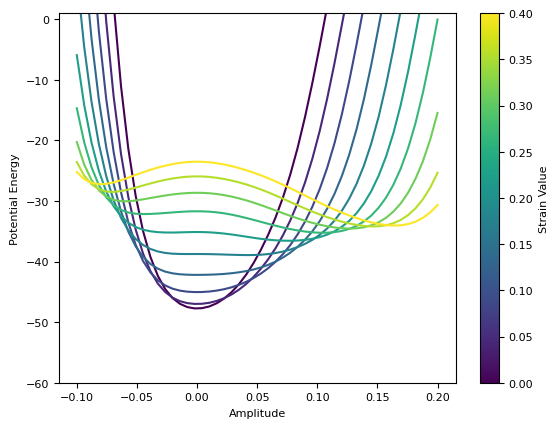

In [137]:
plot_mode_energy(AMODE_ENERGIES)

In [213]:
AS = np.linspace(-0.3, 0.6, 50)
BS = np.linspace(-0.3, 0.3, 50)
strains = np.linspace(0, 0.25, num=10)
deformations = [ID + np.array([[s, 0, 0], [0, s, 0], [0, 0, 0]]) for s in strains]

moddel = MACECalculator("../../MACE.model", device = "cuda")

AMODE = AMode()
BMODE = BMode()

GRID_DATA = {}

GRID_DATA['AS'] = AS
GRID_DATA['BS'] = BS
GRID_DATA['DATA'] = {}

for strain, deformation in tqdm(zip(strains, deformations)):
    cell = KCELL0 @ deformation
    strained_atoms = katoms.copy()
    strained_atoms.set_cell(cell, scale_atoms=True)

    energies = np.zeros(shape=(len(AS), len(BS)))
    for ia, A in enumerate(AS):
        amodded = AMODE.apply(strained_atoms, A)
        for ib, B in enumerate(BS):
            bmodded = BMODE.apply(amodded, B)
            bmodded.calc = model
            energies[ia, ib] = bmodded.get_potential_energy()

    GRID_DATA['DATA'][strain] = energies

/home/gabri/anaconda3/envs/mace/lib/python3.10/site-packages/mace/calculators/mace.py:199: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  torch.load(f=model_path, map_location=device)
/home/gabri/anaconda3/envs/mace/lib/python3.10/site-packages/torch/jit/_serialization.py:176: DeprecationWarning: `torch.jit.load` is deprecated. Please switch to `torch.export`.
  warnings.warn(
/home/gabri/anaconda3/envs/mace/lib/python3.10/site-packages/torch/jit/_serialization.py:176: DeprecationWarning: `torch.jit.load` is deprecated. Please switch to `torch.export`.
  warnings.warn(
10it [18:34, 111.42s/it]


In [218]:
import json

class NumpyEncoder(json.JSONEncoder):
    def default(self, obj):
        if isinstance(obj, np.ndarray):
            return obj.tolist() # Convert arrays to nested lists
        return super().default(obj)
    

with open("GRID_DATA.json", "w") as f:
    json.dump(GRID_DATA, f, cls=NumpyEncoder, indent = 2)

In [229]:
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
import numpy as np

def plot_grid_data_to_pdf(grid_data, filename="energy_surfaces_unique_scales.pdf"):
    AS = grid_data['AS']
    BS = grid_data['BS']
    strains_data = grid_data['DATA']
    
    extent = [BS.min(), BS.max(), AS.min(), AS.max()]

    with PdfPages(filename) as pdf:
        # Sort strains numerically for the PDF order
        for strain in sorted(strains_data.keys()):
            energies = strains_data[strain]
            
            # --- UNIQUE SCALE CALCULATION ---
            # Every page gets its own color limits
            local_min = np.min(energies)
            local_max = local_min + 1 
            
            fig, ax = plt.subplots(figsize=(8, 6))
            
            # We use 'plasma' or 'viridis' for high contrast
            im = ax.imshow(
                energies, 
                extent=extent, 
                origin='lower', 
                aspect='auto', 
                cmap='plasma',
                vmin=local_min, # Unique to this slice
                vmax=local_max  # Unique to this slice
            )
            
            # Define contour levels within this unique 100-unit window
            levels = np.linspace(local_min, local_max, 15)
            ax.contour(BS, AS, energies, levels=levels, colors='white', alpha=0.1)
            
            # Add the colorbar - notice it will show different values on each page
            cbar = plt.colorbar(im, ax=ax)
            cbar.set_label('Potential Energy (eV)', rotation=270, labelpad=15)
            
            ax.set_title(f"Strain: {strain:.4f}")
            ax.set_xlabel("B-Mode Displacement")
            ax.set_ylabel("A-Mode Displacement")
            
            plt.tight_layout()
            pdf.savefig(fig)
            plt.close(fig)
            
    print(f"PDF generated: {filename}. Each page has a unique colorscale.")

# plot_grid_data_to_pdf(GRID_DATA)

In [230]:
plot_grid_data_to_pdf(GRID_DATA)

PDF generated: energy_surfaces_unique_scales.pdf. Each page has a unique colorscale.
